In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import maximum_filter
import math

In [2]:
#Cargar Imagen
ruta = r"C:\Users\eparr\Desktop\STM\Imagen.jpeg"

img = Image.open(ruta).convert("L")
img = np.array(img)

print("Tamaño de la imagen original:", img.shape)

Tamaño de la imagen original: (303, 323)


Tamaño del mapa utilizado: (256, 256)


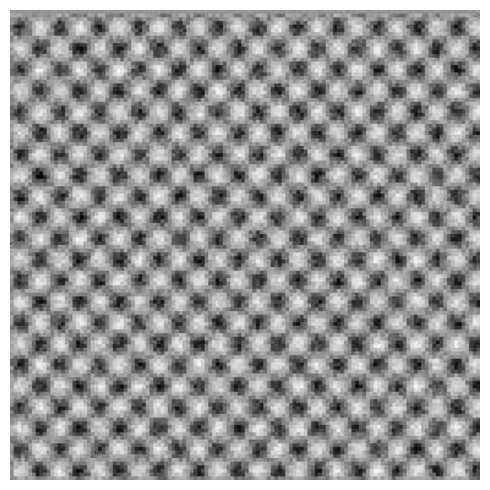

In [4]:
#recortar imagen
z = img[26:282, 21:277]

print("Tamaño del mapa utilizado:", z.shape)

plt.figure(figsize=(5, 5))
plt.imshow(z, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Preprocesamiento
z = z.astype(float)
z = z - np.mean(z)

ny, nx = z.shape

# Ventana Hann 2D
wx = np.hanning(nx)
wy = np.hanning(ny)
window = np.outer(wy, wx)

z_window = z * window

In [11]:
#FFT 2D

fft2 = np.fft.fft2(z_window)
fft_shift = np.fft.fftshift(fft2)

power = np.abs(fft_shift)**2
power_log = np.log10(power + 1)


Lx = 3.99  # nm
Ly = 3.99  # nm

dx = Lx / nx
dy = Ly / ny

fx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))
fy = np.fft.fftshift(np.fft.fftfreq(ny, d=dy))

FX, FY = np.meshgrid(fx, fy)
F = np.sqrt(FX**2 + FY**2)

In [13]:
# Buscar picos

mask = (F > 2.0) & (F < 6.0)

power_search = power.copy()
power_search[~mask] = 0

# Encontrar máximos locales
local_max = (
    power_search ==
    maximum_filter(power_search, size=5)
) & mask

coords = np.argwhere(local_max)
values = power_search[local_max]

# Ordenar los máximos por intensidad
order = np.argsort(values)[::-1]

# Tomar los cuatro picos principales simétricos
coords = coords[order[:4]]


In [15]:
# Refinamiento de posicion con interpolacion parabolica para las frecuencias
log_power = np.log(power + 1)

dfx = fx[1] - fx[0]
dfy = fy[1] - fy[0]


def desplazamiento_parabolico(vm, v0, vp):
    """
    Refinamiento de la posición de un máximo mediante
    interpolación parabólica utilizando tres puntos.
    """
    denom = vm - 2*v0 + vp

    if denom == 0:
        return 0.0

    return 0.5 * (vm - vp) / denom


frecuencias = []
picos = []

for iy, ix in coords:

    # Refinamiento en X
    delta_x = desplazamiento_parabolico(
        log_power[iy, ix - 1],
        log_power[iy, ix],
        log_power[iy, ix + 1]
    )

    # Refinamiento en Y
    delta_y = desplazamiento_parabolico(
        log_power[iy - 1, ix],
        log_power[iy, ix],
        log_power[iy + 1, ix]
    )

    fx_ref = fx[ix] + delta_x * dfx
    fy_ref = fy[iy] + delta_y * dfy

    f_radial = np.sqrt(fx_ref**2 + fy_ref**2)

    frecuencias.append(f_radial)
    picos.append((fx_ref, fy_ref))

frecuencias = np.array(frecuencias)


In [16]:
# Promedio de frecuencia y encontrar periodicidad

f_promedio = np.mean(frecuencias)
f_std = np.std(frecuencias, ddof=1)

# Periodicidad espacial
d = 1 / f_promedio

print("\n--- PICOS PRINCIPALES ---")

for i, f in enumerate(frecuencias, 1):
    print(f"Pico {i}: {f:.4f} nm^-1")

print("\nFrecuencia promedio:")
print(f"f = {f_promedio:.4f} nm^-1")

print("\nPeriodicidad obtenida:")
print(f"d = {d:.4f} nm")




--- PICOS PRINCIPALES ---
Pico 1: 4.0737 nm^-1
Pico 2: 4.0737 nm^-1
Pico 3: 4.0753 nm^-1
Pico 4: 4.0753 nm^-1

Frecuencia promedio:
f = 4.0745 nm^-1

Periodicidad obtenida:
d = 0.2454 nm


In [19]:
# Calculo de incertidumbres

# Resolución de frecuencia de la FFT
delta_f = 1 / Lx

# Incertidumbre estándar asociada a un bin de frecuencia
u_f_bin = delta_f / np.sqrt(12)

# Incertidumbre por dispersión entre los picos
u_f_picos = f_std / np.sqrt(len(frecuencias))

# Incertidumbre asociada a al software
u_L = 0.005 / np.sqrt(3)

# Propagación de la incertidumbre del tamaño espacial
u_f_L = f_promedio * u_L / Lx

# Incertidumbre combinada de la frecuencia
u_f = np.sqrt(u_f_bin**2 + u_f_picos**2 + u_f_L**2)

# u_d = |dd/df| u_f = u_f / f^2
u_d = u_f / f_promedio**2

# Incertidumbre expandida, k = 2
U_d = 2 * u_d

print(f"Resolución FFT = {delta_f:.5f} nm^-1")
print(f"u_f por resolución FFT = {u_f_bin:.5f} nm^-1")
print(f"u_f por dispersión = {u_f_picos:.5f} nm^-1")
print(f"u_f por tamaño de imagen = {u_f_L:.5f} nm^-1")
print(f"u_f combinada = {u_f:.5f} nm^-1")
print(f"u_d = {u_d:.5f} nm")
print(f"U_d (k=2) = {U_d:.5f} nm")

Resolución FFT = 0.25063 nm^-1
u_f por resolución FFT = 0.07235 nm^-1
u_f por dispersión = 0.00044 nm^-1
u_f por tamaño de imagen = 0.00295 nm^-1
u_f combinada = 0.07241 nm^-1
u_d = 0.00436 nm
U_d (k=2) = 0.00872 nm


In [23]:
# Valor teorico
d_teorico = 0.250  # nm
# redondear incertidumbre 
def redondear_incertidumbre_1_sig(valor):
    orden = math.floor(math.log10(abs(valor)))
    decimales = -orden
    valor_red = round(valor, decimales)

    return valor_red, decimales


U_red, decimales = redondear_incertidumbre_1_sig(U_d)
d_red = round(d, decimales)
d_teo_red = round(d_teorico, decimales)

# Comparacion 

diferencia_porcentual = (
    abs(d_teo_red - d_red)
    / d_teo_red
    * 100
)

# Diferencia normalizada por la incertidumbre
z = abs(d_teo_red - d_red) / U_red

In [26]:
# Resultados

print(f"d_sim = ({d_red:.{decimales}f} ± "f"{U_red:.{decimales}f}) nm")

print(f"d_teo = {d_teo_red:.{decimales}f} nm")

print(f"Diferencia porcentual = "f"{diferencia_porcentual:.2f} %")

print(f"|d_teo - d_sim| / U = {z:.2f}")


d_sim = (0.245 ± 0.009) nm
d_teo = 0.250 nm
Diferencia porcentual = 2.00 %
|d_teo - d_sim| / U = 0.56


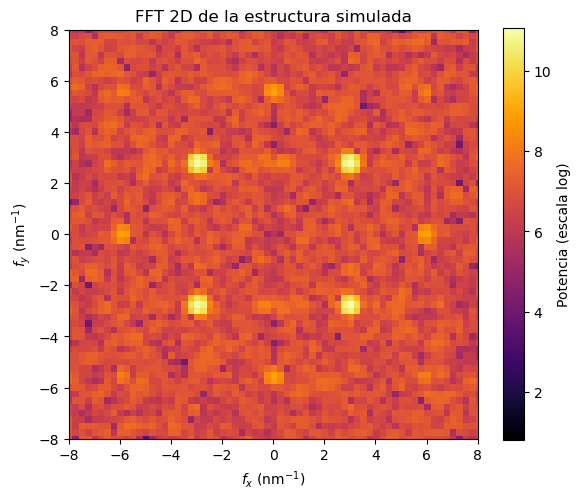

In [28]:
# Grafica de los picos fft
plt.figure(figsize=(6, 5))

plt.imshow(
    power_log,
    extent=[fx[0], fx[-1], fy[0], fy[-1]],
    origin="lower",
    cmap="inferno",
    aspect="equal"
)

plt.xlabel(r"$f_x$ (nm$^{-1}$)")
plt.ylabel(r"$f_y$ (nm$^{-1}$)")
plt.title("FFT 2D de la estructura simulada")

plt.xlim(-8, 8)
plt.ylim(-8, 8)

plt.colorbar(label="Potencia (escala log)")
plt.tight_layout()
plt.show()